# Comparison of Empirical Results to Mathematical Analysis

## Setup

In [2]:
# General imports
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl 
import numpy as np
import random
import math
import networkx as nx
import itertools
import warnings
warnings.filterwarnings("ignore")

# MSEAN imports
from msean import load_config, save_config
from msean.analysis.numerical_integration import gen_expected_weighting_lookup, trapezoidal_pairwise_connection_prob, find_closest_coords, p_delta, normalise_as_pdf, sq_line_picking_prob
from msean.analysis.numerical_integration import sq_line_picking_prob, catchment_area, mc_voronoi_pairwise_connection_prob, trapezoidal_voronoi_pairwise_connection_prob
from msean.generation.connect import d
from msean.generation import gen
from msean.measurements import get_triangles, get_density

Load configuration from file <b>configs/default.yaml</b>.

In [3]:
# Load configuration file
root = Path.cwd().parents[0] # go up from notebooks/ to project root
cfg = load_config(root / "configs" / "default.yaml")
runs_dir = root / "runs"

In [4]:
rng = np.random.default_rng(cfg.seed)

In [6]:
cfg.connection.alpha = 2**(-10)
G, layers = gen(cfg, rng)

In [8]:
deg = [d for v, d in G.degree]

## Connection Function

$\omega(d(\mathbf x_u, \mathbf x_{a^\ell_i})) = \exp\left({- \frac{d(\mathbf x_u, \mathbf x_{a^\ell_i})}{\alpha \sqrt{2}}}\right)$ 

As $\alpha$ increases, spatial strength decreases and the probability of connection becomes flatter across scales.

In [4]:
alphas = [0.01 * 2**i for i in range(1, 13)]

deltas = np.linspace(0, math.sqrt(2),101)[:-1]
connection_fs = []

for alpha in alphas:
    connection_fs.append([math.exp(-delta/(math.sqrt(2)*alpha)) for delta in deltas])

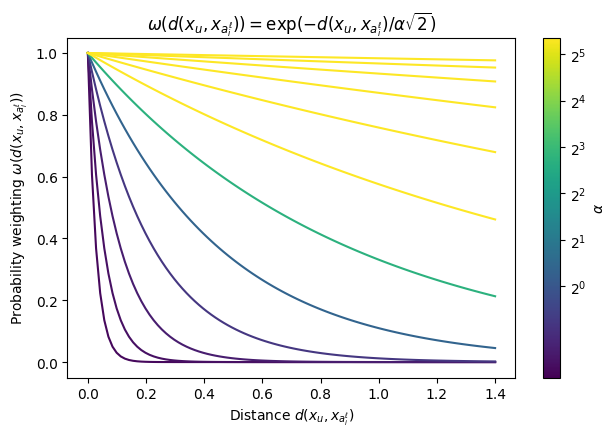

In [5]:
# Plot the connection function against α
fig = plt.figure(figsize=(8,4))
ax = fig.add_axes([0.10,0.10,0.70,0.85])

colormap = plt.cm.viridis

for alpha, probs in zip(alphas, connection_fs):
    plt.plot(deltas, probs, color=colormap(alpha))

sm = plt.cm.ScalarMappable(cmap = colormap, norm=mpl.colors.SymLogNorm(1, vmin=alphas[0], vmax=alphas[-1], base=2))
plt.colorbar(sm, ax=ax, label='$\\alpha$')

plt.xlabel('Distance $d(x_u, x_{a^\\ell_i})$')
plt.ylabel('Probability weighting $\\omega(d(x_u, x_{a^\\ell_i}))$')

plt.title('$\\omega(d(x_u, x_{a^\\ell_i})) = \\exp(-{d(x_u, x_{a^\\ell_i})} / {\\alpha \\sqrt{2}})$')
plt.show()

## Expected Weighting for Nodes

$\overline \omega (\mathbf x_u) 
= \int_0^1 \omega (d (\mathbf x_u, \mathbf x_{a^\ell_i})) 
\cdot f_{\mathbf X_{\mathcal A}}(\mathbf x_{a^\ell_i}) 
~ \text{d}\mathbf x_{a^\ell_i}$

Generate a lookup table for the expected weighting of a node at each position.

In [5]:
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)

When $\alpha$ is high, the connection function decays slowly and so on average values of $\omega$ are higher. Nodes near the centre have higher values of $\overline \omega$ because they are closer to all possible affiliation positions on average, compared to nodes near the corners. When $\alpha$ is low, average values of $\omega$ are lower and more evenly spread.

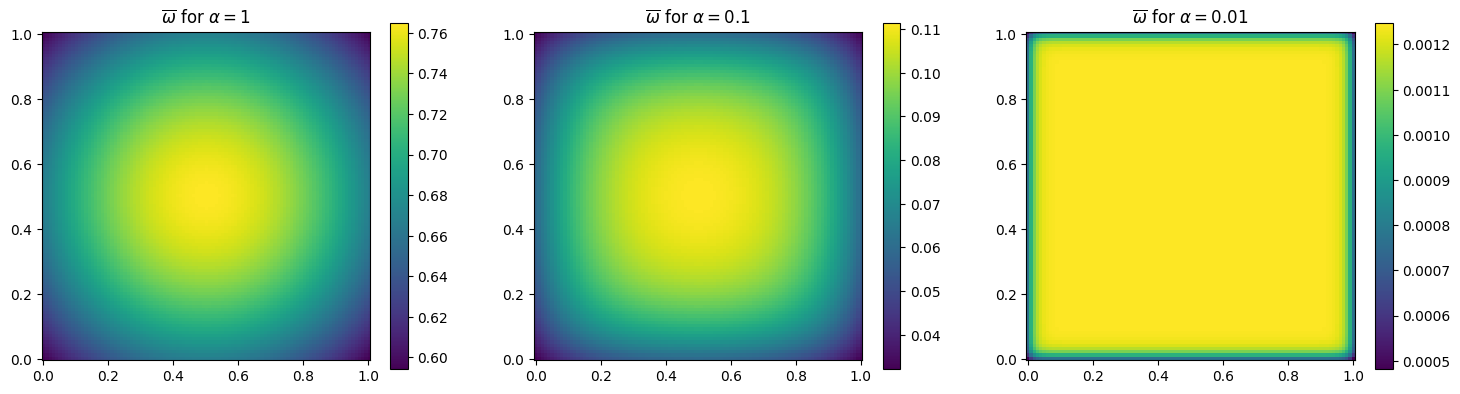

In [7]:
# Plot the expected weighting values
original_alpha = cfg.connection.alpha
fig, axs = plt.subplots(1, 3, figsize = (18, 6))

# High alpha
high_alpha = 1
cfg.connection.alpha = high_alpha
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)
im = axs[0].imshow(weighting_lkup)
fig.colorbar(im, shrink=0.75)
axs[0].set_xticklabels([i/100 for i in axs[0].get_xticks()])
axs[0].set_yticklabels([i/100 for i in axs[0].get_yticks()])
axs[0].invert_yaxis()
axs[0].set_title("$\overline{\\omega}$ for $\\alpha=$" + str(high_alpha))

# Medium alpha
high_alpha = 0.1
cfg.connection.alpha = high_alpha
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)
im = axs[1].imshow(weighting_lkup)
fig.colorbar(im, shrink=0.75)
axs[1].set_xticklabels([i/100 for i in axs[0].get_xticks()])
axs[1].set_yticklabels([i/100 for i in axs[0].get_yticks()])
axs[1].invert_yaxis()
axs[1].set_title("$\overline{\\omega}$ for $\\alpha=$" + str(high_alpha))

# Low alpha
low_alpha = 0.01
cfg.connection.alpha = low_alpha
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)
im = axs[2].imshow(weighting_lkup)
fig.colorbar(im, shrink=0.75)
axs[2].set_xticklabels([i/100 for i in axs[1].get_xticks()])
axs[2].set_yticklabels([i/100 for i in axs[1].get_yticks()])
axs[2].invert_yaxis()
axs[2].set_title("$\overline{\\omega}$ for $\\alpha=$" + str(low_alpha))

cfg.connection.alpha = original_alpha # Reset alpha
plt.show()

## Pairwise Connection Probabilities

### Uniform Case

In the uniform case, two nodes connect in layer $\ell$ with probability $1/(K^\ell)$.

In [28]:
# Probability that two nodes choose the same affiliation with K = 100

u_pos = (random.uniform(0, 1), random.uniform(0,1))
v_pos = (random.uniform(0, 1), random.uniform(0,1))

alpha = 10
K = 100

n_trials = 100_000

successes = 0
for _ in range(n_trials):
    aff_pos = {aff : (random.uniform(0, 1), random.uniform(0,1)) for aff in range(K)}

    weightings_u = {aff : math.e ** (-d(u_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}
    weightings_v = {aff : math.e ** (-d(v_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}

    Z_u = sum([weightings_u[aff] for aff in aff_pos])
    Z_v = sum([weightings_v[aff] for aff in aff_pos])

    probs_u = {aff : weightings_u[aff] / Z_u for aff in aff_pos}
    probs_v = {aff : weightings_v[aff] / Z_v for aff in aff_pos}

    aff_u = np.random.choice([aff for aff in aff_pos], p = [probs_u[aff] for aff in aff_pos])
    aff_v = np.random.choice([aff for aff in aff_pos], p = [probs_v[aff] for aff in aff_pos])

    if aff_u == aff_v: successes += 1
    
print(successes / n_trials)

0.01052


### TO DO Voronoi Case

In the Voronoi case, two nodes connect in layer $\ell$ if they fall into the same Voronoi cell.

In [35]:
# Probability that two nodes choose the same affiliation with K = 100

u_pos = (random.uniform(0.48, 0.52), random.uniform(0.48, 0.52))
v_pos = (random.uniform(0.48, 0.52), random.uniform(0.48, 0.52))

alpha = 0.001
K = 100

n_trials = 100_000

successes = 0
for _ in range(n_trials):
    aff_pos = {aff : (random.uniform(0, 1), random.uniform(0,1)) for aff in range(K)}

    weightings_u = {aff : math.e ** (-d(u_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}
    weightings_v = {aff : math.e ** (-d(v_pos, aff_pos[aff], cfg)/(math.sqrt(2) * alpha)) for aff in aff_pos}

    Z_u = sum([weightings_u[aff] for aff in aff_pos])
    Z_v = sum([weightings_v[aff] for aff in aff_pos])

    probs_u = {aff : weightings_u[aff] / Z_u for aff in aff_pos}
    probs_v = {aff : weightings_v[aff] / Z_v for aff in aff_pos}

    aff_u = np.random.choice([aff for aff in aff_pos], p = [probs_u[aff] for aff in aff_pos])
    aff_v = np.random.choice([aff for aff in aff_pos], p = [probs_v[aff] for aff in aff_pos])

    if aff_u == aff_v: successes += 1
    
print(successes / n_trials)

0.91982


In [36]:
trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 100)

0.884084098347485

Experiments with density

In [31]:
n = 200_000
K = 100

total = 0

for _ in range(n):
    pos_u = (random.uniform(0,1), random.uniform(0,1))
    pos_v = (random.uniform(0,1), random.uniform(0,1))

    total += trapezoidal_voronoi_pairwise_connection_prob(cfg, pos_u, pos_v, K)

total / n

(0.6342399682042404, 0.25259702345221435) (0.4669279523303286, 0.8394953583516833) (np.float64(0.5666666666666667), np.float64(0.23333333333333334)) 0.14053100494459164 0.07026550247229538 1.0000000000000062


ValueError: math domain error

In [10]:
quadrt_n = 25
K = 100

total = 0 
for x_u in np.linspace(0, 1, quadrt_n):
    for y_u in np.linspace(0, 1, quadrt_n):
        for x_v in np.linspace(0, 1, quadrt_n):
            for y_v in np.linspace(0, 1, quadrt_n):
                total += trapezoidal_voronoi_pairwise_connection_prob(cfg, (x_u, y_u), (x_v, y_v), K)

total / (quadrt_n ** 4)

0.010278634698551212

In [9]:
quadrt_n = 20
K = 100

total = 0 
for x_u in np.linspace(0, 1, quadrt_n):
    for y_u in np.linspace(0, 1, quadrt_n):
        for x_v in np.linspace(0, 1, quadrt_n):
            for y_v in np.linspace(0, 1, quadrt_n):
                total += trapezoidal_voronoi_pairwise_connection_prob(cfg, (x_u, y_u), (x_v, y_v), K)

total / (quadrt_n ** 4)

0.01019632980340346

## Triangle Counts

### Uniform Case

In [18]:
def _triangle_layer_dimension(edge_layers):
    e1, e2, e3 = edge_layers

    if e1 & e2 & e3:
        return 1

    all_layers = e1 | e2 | e3

    for a in all_layers:
        for b in all_layers:
            pair = {a, b}

            if (
                e1 & pair
                and e2 & pair
                and e3 & pair
            ):
                return 2

    return 3

In [19]:
def get_triangle_dimension_counts(G, layers):
    """
    Returns [n_1d, n_2d, n_3d] triangle counts.

    1d: triangle can be realized in one layer
    2d: triangle needs exactly two layers
    3d: triangle needs exactly three layers
    """
    edge_to_layers = {}

    for layer_idx, layer in enumerate(layers):
        for u, v in layer.edges():
            edge = frozenset((u, v))
            edge_to_layers.setdefault(edge, set()).add(layer_idx)

    counts = np.zeros(3, dtype=float)

    node_order = {node: i for i, node in enumerate(G.nodes())}
    neighbors = {node: set(G.neighbors(node)) for node in G.nodes()}

    for u in G.nodes():
        for v in neighbors[u]:
            if node_order[v] <= node_order[u]:
                continue

            common = neighbors[u] & neighbors[v]

            for w in common:
                if node_order[w] <= node_order[v]:
                    continue

                edge_layers = [
                    edge_to_layers[frozenset((u, v))],
                    edge_to_layers[frozenset((u, w))],
                    edge_to_layers[frozenset((v, w))],
                ]

                dim = _triangle_layer_dimension(edge_layers)

                counts[dim - 1] += 1

    return counts

In [35]:
# Empirical Tests

original_alpha = cfg.connection.alpha
cfg.connection.alpha = 100

avg_triangle_dimension_counts = [0, 0, 0]
for _ in range(cfg.analysis.mc_n_trials):
    G, layers = gen(cfg, rng)
    dim_counts = get_triangle_dimension_counts(G, layers)
    avg_triangle_dimension_counts = [sum([total_count, new_count]) for total_count, new_count in zip(avg_triangle_dimension_counts, dim_counts)]

avg_triangle_dimension_counts = [int(total / cfg.analysis.mc_n_trials) for total in avg_triangle_dimension_counts]
cfg.connection.alpha = original_alpha

print(f'The average number of one-dimensional triangles is {avg_triangle_dimension_counts[0]}.')
print(f'The average number of two-dimensional triangles is {avg_triangle_dimension_counts[1]}.')
print(f'The average number of three-dimensional triangles is {avg_triangle_dimension_counts[2]}.')

The average number of one-dimensional triangles is 352763.
The average number of two-dimensional triangles is 0.
The average number of three-dimensional triangles is 17598.


#### One-Dimensional Triangles

The expected number of one-dimensional triangles is given by $\tau_{\text{1D}} = {N \choose 3} \cdot \left [ 1 - \prod_{\ell=1}^L \left(1 - \frac{1}{(K^\ell)^2} \right)\right]$

In [4]:
def expected_1D_triangles(N, Ks):
    return math.comb(N, 3) * (1 - math.prod([1 - (1/(K**2)) for K in Ks]))

In [5]:
print(f'The expected number of one-dimensional triangles is {expected_1D_triangles(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of one-dimensional triangles is 353992.92284777603.


For the parameters used in the paper, this is:

In [6]:
print(f'The expected number of one-dimensional triangles is {expected_1D_triangles(10_000, [650,4350,475,150,130])}.')

The expected number of one-dimensional triangles is 18405233.049136844.


#### Three-Dimensional Triangles

The expected number of three-dimensional triangles is given by <br>
$\tau_{\text{3D}} = {N\choose 3} \left[ \prod_{\ell = 1}^L \left(1 - \frac{1}{(K^\ell)^2} \right)
    -
    3\prod_{\ell=1}^L \left(1 - \frac{1}{{K^\ell}}\right) 
    +
    3 \prod_{\ell=1}^L \left(1 - \frac{2}{K^\ell} + \frac{1}{(K^\ell)^2}\right) 
    -
    \prod_{\ell=1}^L \left(1 - \frac{3}{K^\ell} + \frac{2}{(K^\ell)^2}\right) \right]$
 <br>This count only includes three-dimensional triangles which do not have one-dimensional equivalents.

In [7]:
def expected_3D_triangles(N, Ks):
    return math.comb(N, 3) * (math.prod([1 - (1/(K**2)) for K in Ks]) 
    - 3 * math.prod([1 - (1/K) for K in Ks])
    + 3 * math.prod([(1 - (2/K) + (1/K**2)) for K in Ks])
    - math.prod([(1 - (3/K) + (2/K**2)) for K in Ks]))

In [8]:
print(f'The expected number of three-dimensional triangles is {expected_3D_triangles(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of three-dimensional triangles is 17714.512254549893.


For the parameters used in the paper, this is:

In [10]:
print(f'The expected number of three-dimensional triangles is {expected_3D_triangles(10_000, [650,4350,475,150,130])}.')

The expected number of three-dimensional triangles is 252744.37353335798.


#### Total Triangles

The expected number of total triangles is given by <br> 
$\tau = {N \choose 3} \cdot \left [ 1 
    -
    3\prod_{\ell=1}^L \left(1 - \frac{1}{{K^\ell}}\right) 
    +
    3 \prod_{\ell=1}^L \left(1 - \frac{2}{K^\ell} + \frac{1}{(K^\ell)^2}\right) 
    -
    \prod_{\ell=1}^L \left(1 - \frac{3}{K^\ell} + \frac{2}{(K^\ell)^2}\right) \right]$

In [35]:
def expected_triangles(N, Ks):
    return math.comb(N, 3) * (1 
    - 3 * math.prod([1 - (1/K) for K in Ks])
    + 3 * math.prod([(1 - (2/K) + (1/K**2)) for K in Ks])
    - math.prod([(1 - (3/K) + (2/K**2)) for K in Ks]))

In [14]:
print(f'The expected number of triangles is {expected_triangles(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of triangles is 371707.4351023444.


For the parameters used in the paper, this is:

In [15]:
print(f'The expected number of triangles is {expected_triangles(10_000, [650,4350,475,150,130])}.')

The expected number of triangles is 18657977.4226702.


## Clustering Coefficients

### Uniform Case

Wedge Counts

In [ ]:
# Empirical Tests

original_alpha = cfg.connection.alpha
cfg.connection.alpha = 100

avg_wedge_dimension_counts = [0, 0]
for _ in range(cfg.analysis.mc_n_trials):
    G, layers = gen(cfg, rng)
    dim_counts = get_triangle_dimension_counts(G, layers)

    no_1D_wedges = 3 * dim_counts[0]
    total_wedges = sum([math.comb(d, 2) for v, d in G.degree])

    avg_wedge_dimension_counts[0] += no_1D_wedges
    avg_wedge_dimension_counts[1] += total_wedges - no_1D_wedges

avg_wedge_dimension_counts = [int(total / cfg.analysis.mc_n_trials) for total in avg_wedge_dimension_counts]
cfg.connection.alpha = original_alpha

print(f'The average number of one-dimensional wedges is {avg_wedge_dimension_counts[0]}.')
print(f'The average number of two-dimensional wedges is {avg_wedge_dimension_counts[1]}.')

[np.float64(10600608.0), np.float64(17792932.0)]
The average number of one-dimensional wedges is 1060060.
The average number of two-dimensional wedges is 1779293.


Global Clustering

In [41]:
# Empirical Tests

original_alpha = cfg.connection.alpha
cfg.connection.alpha = 100

avg_transitivity = 0
for _ in range(cfg.analysis.mc_n_trials):
    G, layers = gen(cfg, rng)
    avg_transitivity += nx.transitivity(G)

avg_transitivity /= cfg.analysis.mc_n_trials
cfg.connection.alpha = original_alpha

print(f'The average global clustering coefficient is {avg_transitivity}.')

The average global clustering coefficient is 0.3922979864776049.


#### One-Dimensional Wedges

Every triplet of nodes $u, v, w$ in the same affiliation in layer $\ell$ creates 3 wedges in layer $\ell$. Therefore, the number of one-dimensional wedges in $G$ is the number of one-dimensional triangles times 3. 

In [329]:
print(f'The expected number of one-dimensional wedges is {3 * expected_1D_triangles(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of one-dimensional wedges is 1061978.7685433282.


For the parameters used in the paper, this is:

In [330]:
print(f'The expected number of one-dimensional wedges is {3 * expected_1D_triangles(10_000, [650,4350,475,150,130])}.')

The expected number of one-dimensional wedges is 55215699.14741053.


#### Two-Dimensional Wedges

The expected number of two-dimensional wedges which do not have one-dimensional wedges is given by, <br>
$3 \cdot {N \choose 3} \left[
    \prod_{\ell = 1}^L \left(1 - \frac{1}{(K^\ell)^2} \right) 
    -
    2 \prod_{\ell = 1}^L \left(1 - \frac{1}{K^\ell} \right) 
    +
    \prod_{\ell = 1}^L \left (\frac{(K^\ell - 1)^2}{(K^\ell)^2} \right ) \right]$

In [341]:
def expected_2D_wedges(N, Ks):
    return 3 * math.comb(N, 3) * (math.prod([1 - (1/(K**2)) for K in Ks]) 
    - 2 * math.prod([1 - (1/K) for K in Ks])
    + math.prod([(1 - (1/K))**2 for K in Ks]))

In [ ]:
print(f'The expected number of two-dimensional wedges is {expected_2D_wedges(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of one-dimensional wedges is 1785762.0960957322.


For the parameters used in the paper, this is:

In [344]:
print(f'The expected number of two-dimensional wedges is {expected_2D_wedges(10_000, [650,4350,475,150,130])}.')

The expected number of two-dimensional wedges is 108935988.65229969.


#### Total Wedges

The total expected number of wedges is given by, <br>
$ 3 \cdot{N \choose 3} \cdot \left [ 1  
    -
    2 \prod_{\ell = 1}^L \left(1 - \frac{1}{K^\ell} \right) 
    +
    \prod_{\ell = 1}^L \left (\frac{(K^\ell - 1)^2}{(K^\ell)^2} \right ) \right]$

In [43]:
def expected_wedges(N, Ks):
    return 3 * math.comb(N, 3) * (1
    - 2 * math.prod([1 - (1/K) for K in Ks])
    + math.prod([(1 - (1/K))**2 for K in Ks]))

In [44]:
print(f'The expected number of wedges is {expected_wedges(cfg.network.n_nodes, cfg.network.n_affiliations)}.')

The expected number of wedges is 2847740.86463906.


For the parameters used in the paper, this is:

In [45]:
print(f'The expected number of wedges is {expected_wedges(10_000, [650,4350,475,150,130])}.')

The expected number of wedges is 164151687.7997102.


####  TO DO Needs sorting out

In [43]:
expected_rho = 1 - math.prod([1 - 1/(K) for K in cfg.network.n_affiliations])
expected_rho

0.07558179759999994

In [44]:
expected_kappa = (cfg.network.n_nodes - 1) * expected_rho
expected_kappa

75.50621580239995

In [45]:
n = expected_kappa
k = 2

math.gamma(n + 1) / (math.gamma(k+1)*math.gamma(n-k+1))

2812.8412044980964

In [22]:
cfg.network.n_nodes * math.gamma(n + 1) / (math.gamma(k+1)*math.gamma(n-k+1))

2812841.2044980964

In [20]:
math.comb(76, 2)

2850

In [21]:
math.comb(75, 2)

2775

In [33]:
original_alpha = cfg.connection.alpha

cfg.connection.alpha = 100

n = 100
total_C = 0
total_c = 0

for _ in range(n):
    G, _ = gen(cfg, rng)
    total_C += nx.transitivity(G)
    total_c += nx.average_clustering(G)

cfg.connection.alpha = original_alpha

total_C / n, total_c / n

(0.39158024762207255, 0.39158485778914487)

In [36]:
math.comb(cfg.network.n_nodes - 1, 2) * expected_triangles(cfg.network.n_nodes, cfg.network.n_affiliations) / math.comb(cfg.network.n_nodes, 3)

1115.122305307033

In [46]:
math.gamma(n + 1) / (math.gamma(k+1)*math.gamma(n-k+1))

2812.8412044980964

In [49]:
1115.122305307033 / 2812.8412044980964

0.39643983582287134

In [42]:
np.mean([nx.triangles(G, u) for u in G])

np.float64(1111.323)

In [28]:
nx.average_clustering(G)

0.3872055756085941

In [31]:
nx.transitivity(G)

0.38468313636712187

In [50]:
original_alpha = cfg.connection.alpha

cfg.connection.alpha = 100

G, layers = gen(cfg, rng)

cfg.connection.alpha = original_alpha

In [68]:
avg_total = 0
avg_1D = 0

for node in G:
    count = 0
    for triangle in nx.all_triangles(G, node):
        if triangle in nx.all_triangles(layers[0], 'u1') or triangle in nx.all_triangles(layers[1], 'u1') or triangle in nx.all_triangles(layers[2], 'u1') or triangle in nx.all_triangles(layers[3], 'u1') or triangle in nx.all_triangles(layers[4], 'u1'):
            count += 1

    avg_total += nx.triangles(G, node)
    avg_1D += count

avg_total, avg_1D

(1108785, 1593)

#### Global Clustering Coefficient

In [355]:
def expected_transitivity(N, Ks):
    no_triangles = expected_1D_triangles(N, Ks) + expected_3D_triangles(N, Ks)
    no_wedges = 3 * expected_1D_triangles(N, Ks) + expected_2D_wedges(N, Ks)

    return 3 * no_triangles / no_wedges

In [356]:
expected_transitivity(cfg.network.n_nodes, cfg.network.n_affiliations)

0.39158138268606646

In [357]:
expected_transitivity(10_000, [650,4350,475,150,130])

0.34098907552085134

## Degree Distributions

In [133]:
N = 10_000
Ks = [650,4350,475,150,130]
p = 1 - math.prod([1 - 1/K for K in Ks])
xs = [x for x in range(N)]
cs = [math.comb(N-1, k) for k in xs]
qs = [(p**k) * ((1-p)**(N-1-k)) for k in xs]

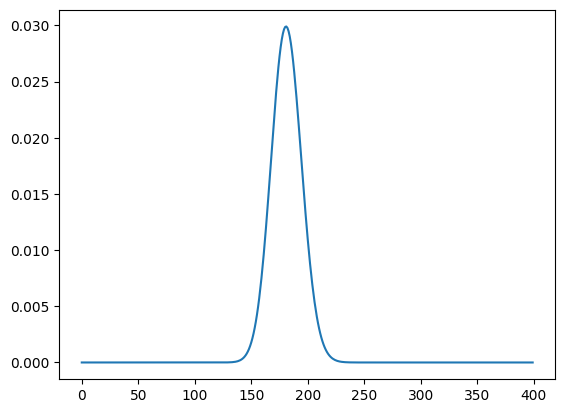

In [156]:
from scipy.stats import binom
lim = 400
dist = [binom.pmf(r, N, p) for r in xs[:lim]]
plt.plot(xs[:lim], dist)

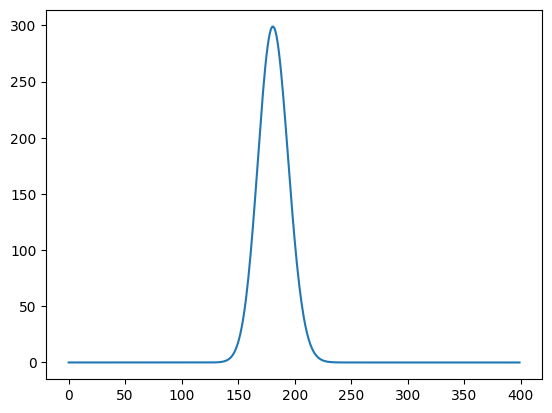

In [158]:
from scipy.stats import binom
lim = 400
dist = [N*binom.pmf(r, N-1, p) for r in xs[:lim]]
plt.plot(xs[:lim], dist)

# TO SORT OUT

<i> Below here needs working on

The Effect of $\alpha$ on the Probability of Nodes Connecting

In [19]:
original_alpha = cfg.connection.alpha
alphas = [i*0.05 for i in range(1,21)] 

deltas = np.linspace(0,math.sqrt(2),51)[:-1]
p_deltas_arr = []

for alpha in alphas:
    cfg.connection.alpha = alpha
    p_deltas = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=100) for delta in deltas]
    p_deltas_arr.append(p_deltas)

cfg.connection.alpha = original_alpha # Reset alpha

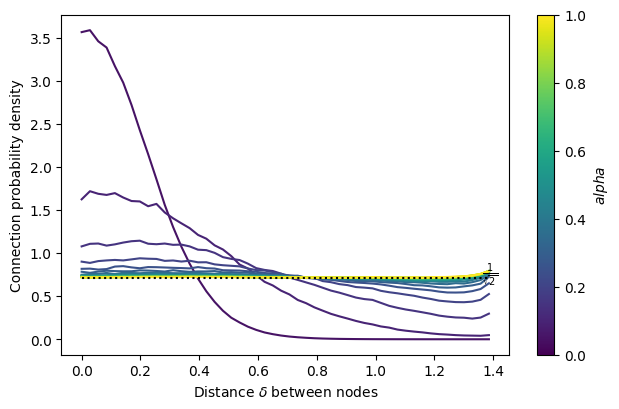

In [25]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_axes([0.10,0.10,0.70,0.85])

colormap = plt.cm.viridis

step = deltas[1] - deltas[0]

for a, probs in zip(alphas, p_deltas_arr):
    normalised_probs = normalise_as_pdf(probs, step)
    plt.plot(deltas, normalised_probs, label=f'$alpha = ${a:.2f}', color=colormap(a))

sm = plt.cm.ScalarMappable(cmap = colormap)
sm.set_array([])
plt.plot(deltas, [1/math.sqrt(2) for _ in deltas], ls=':', color='black')
plt.colorbar(sm, ax=ax, label='$alpha$')

plt.xlabel('Distance $\\delta$ between nodes')
plt.ylabel('Connection probability density')
plt.annotate('$\\frac{1}{\\sqrt{2}}$', (1.362, 1/math.sqrt(2)))

plt.show()

<i> Why does it go up at the end? It didn't do that before

In [ ]:
import winsound
frequency = 1600  # Set Frequency To 2500 Hertz
duration = 800  # Set Duration To 1000 ms == 1 second

In [114]:
from msean.generation.connect import d

def find_closest(cfg, vals, x):
    return np.argmin([abs(c - x) for c in vals])

def empirical_p_deltas(cfg, deltas):
    n_graphs = 1000
    n_node_pairs = 10000

    connected_pairs = [0 for delta in deltas]
    all_pairs = [0 for delta in deltas]

    for _ in range(n_graphs):
        G, _ = gen(cfg, rng)
        for _ in range(n_node_pairs):
            u, v = random.sample(list(G.nodes), 2)
            d_uv = d(G.nodes[u]['embedding'], G.nodes[v]['embedding'], cfg)
            i_d = find_closest(cfg, deltas, d_uv)
            if (u, v) in G.edges:
                connected_pairs[i_d] += 1
            all_pairs[i_d] += 1

    return connected_pairs, all_pairs

Small $\alpha$

In [99]:
original_alpha = cfg.connection.alpha
alpha = 0.01
#alphas = [i*0.05 for i in range(1,21)] 

deltas = np.linspace(0,math.sqrt(2),51)[:-1]
cfg.connection.alpha = alpha
p_deltas = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=100) for delta in deltas]

connected_pairs, all_pairs = empirical_p_deltas(cfg, deltas)
prob_connected = [c/T if T!=0 else 0 for c, T in zip(connected_pairs, all_pairs)]

cfg.connection.alpha = original_alpha # Reset alpha

winsound.Beep(frequency, duration)

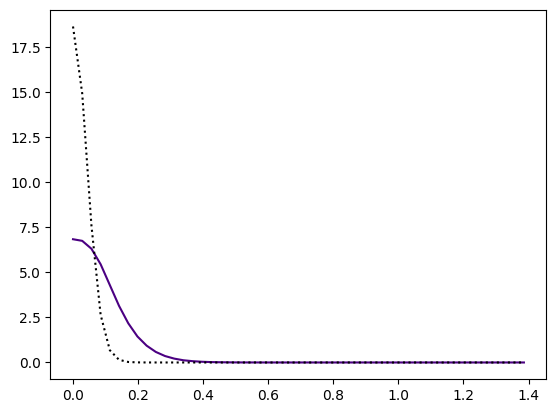

In [100]:
step = deltas[1] - deltas[0]

normalised_analytical_probs = normalise_as_pdf(p_deltas, step)
normalised_empirical_probs = normalise_as_pdf(prob_connected, step)

plt.plot(deltas, normalised_empirical_probs, color='indigo')
plt.plot(deltas, normalised_analytical_probs, ls=":", color='black')

Large $\alpha$

In [115]:
original_alpha = cfg.connection.alpha
alpha = 0.2
#alphas = [i*0.05 for i in range(1,21)] 

deltas = np.linspace(0,math.sqrt(2),51)[:-1]
cfg.connection.alpha = alpha
p_deltas = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=100) for delta in deltas]

connected_pairs, all_pairs = empirical_p_deltas(cfg, deltas)
prob_connected = [c/T if T!=0 else 0 for c, T in zip(connected_pairs, all_pairs)]

cfg.connection.alpha = original_alpha # Reset alpha

winsound.Beep(frequency, duration)

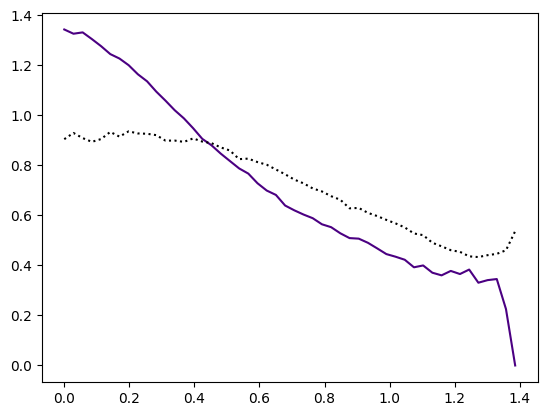

In [116]:
step = deltas[1] - deltas[0]

normalised_analytical_probs = normalise_as_pdf(p_deltas, step)
normalised_empirical_probs = normalise_as_pdf(prob_connected, step)

plt.plot(deltas, normalised_empirical_probs, color='indigo')
plt.plot(deltas, normalised_analytical_probs, ls=":", color='black')

### TO DO Network Density

Network density increases as $r_0 \to 0$.

In [99]:
r_0s = [0.005, 0.01, 0.015, 0.02] + [0.025 * i for i in range(1,41)]

Empirical results:

<i> Replace this code with the batch code

In [5]:
alphas = [0.005, 0.01, 0.015, 0.02] + [0.025 * i for i in range(1,41)]

In [16]:
original_n_trials = cfg.analysis.mc_n_trials
original_alpha = cfg.connection.alpha
original_L = cfg.network.n_layers 

cfg.network.n_layers = 1
cfg.analysis.mc_n_trials = 10

empirical_rhos = []

for alpha in alphas:
    total = 0
    cfg.connection.alpha = alpha
    for _ in range(cfg.analysis.mc_n_trials):
        G, layers = gen(cfg, rng)
        total += nx.density(G)
    empirical_rhos.append(total / cfg.analysis.mc_n_trials)

cfg.connection.alpha = original_alpha #Reset r_0
cfg.network.n_layers = original_L
cfg.analysis.mc_n_trials = original_n_trials

Plot the empirical results.

In [14]:
original_alpha = cfg.connection.alpha
original_L = cfg.network.n_layers 
original_N = cfg.network.n_nodes
original_K = cfg.network.n_affiliations

cfg.network.n_layers = 1
cfg.network.n_nodes = 100
cfg.network.n_affiliations = [10]

cfg.connection.alpha = 0.001
voronoi_G, layers = gen(cfg, rng)

cfg.connection.alpha = 0.05
mixed_G, layers = gen(cfg, rng)

cfg.connection.alpha = 1
er_G, layers = gen(cfg, rng)

cfg.connection.alpha = original_alpha #Reset r_0
cfg.network.n_layers = original_L
cfg.network.n_nodes = original_N
cfg.network.n_affiliations = original_K

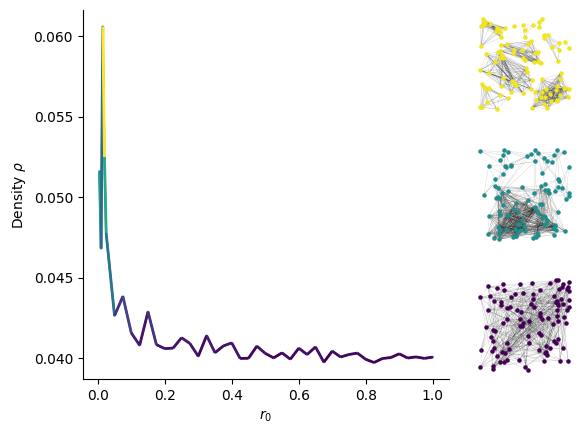

In [15]:
fig = plt.figure()
gs = plt.GridSpec(3, 4, figure=fig)
ax_rhos = fig.add_subplot(gs[:, :3])

ax_voronoi = fig.add_subplot(gs[0, 3])
ax_mixed = fig.add_subplot(gs[1, 3])
ax_er = fig.add_subplot(gs[2, 3])

ax_rhos.plot(alphas, empirical_rhos) #, color='navy')
#ax_rhos.plot(r_0s, [1.28/cfg.network.n_affiliations[0] for r_0 in r_0s], color='crimson', ls=':')
#ax_rhos.plot(r_0s, [1/cfg.network.n_affiliations[0] for r_0 in r_0s], color='crimson', ls=':')
ax_rhos.set_xlabel('$r_0$')
ax_rhos.set_ylabel('Density $\\rho$')

ax_rhos.spines['top'].set_visible(False)
ax_rhos.spines['right'].set_visible(False)

points = np.array([alphas, empirical_rhos]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a continuous norm to map from data points to colors
norm = plt.Normalize(min(empirical_rhos), max(empirical_rhos))
lc = mpl.collections.LineCollection(segments, cmap='viridis', norm=norm)
# Set the values used for colormapping
lc.set_array(empirical_rhos)
lc.set_linewidth(2)
line = ax_rhos.add_collection(lc)

#ax_rhos.set_yticks(np.append(ax_rhos.get_yticks(), 0.0128))

arrow = mpl.patches.FancyArrowPatch((1.025, 0.01135), (1.025, 0.0124), arrowstyle='<->,head_width=.15', mutation_scale=10)
ax_rhos.add_patch(arrow)
ax_rhos.annotate('Voronoi', (1.008, 0.0125), rotation=90)
ax_rhos.annotate('Space-Independent', (1.008, 0.0101), rotation=90)

nx.draw(voronoi_G, pos={v: voronoi_G.nodes[v]['embedding'] for v in voronoi_G}, node_color=plt.cm.viridis(250), node_size=5, width=0.05, ax=ax_voronoi)
nx.draw(mixed_G, pos={v: mixed_G.nodes[v]['embedding'] for v in mixed_G}, node_color=plt.cm.viridis(125), node_size=5, width=0.05, ax=ax_mixed)
nx.draw(er_G, pos={v: er_G.nodes[v]['embedding'] for v in er_G}, node_color=plt.cm.viridis(0), node_size=5, width=0.05, ax=ax_er)

plt.show()

In [152]:
probs = []
for i, r_0 in enumerate(r_0s):
    layer_densities = [empirical_rhos[i][j] for j in [1, 2, 3]]
    prob = 1 - np.prod([1 - rho for rho in layer_densities])
    probs.append(prob)

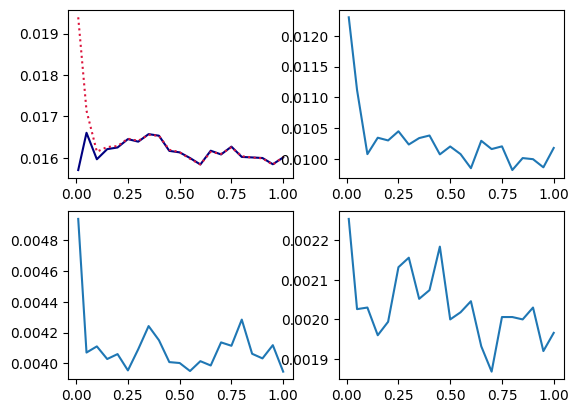

In [153]:
fig, ((axG, ax1), (ax2, ax3)) = plt.subplots(2, 2)
axG.plot(r_0s, [empirical_rhos[i][0] for i in range(len(r_0s))], color='navy')
axG.plot(r_0s, probs, color='crimson', ls=':')
ax1.plot(r_0s, [empirical_rhos[i][1] for i in range(len(r_0s))])
ax2.plot(r_0s, [empirical_rhos[i][2] for i in range(len(r_0s))])
ax3.plot(r_0s, [empirical_rhos[i][3] for i in range(len(r_0s))])
plt.show()

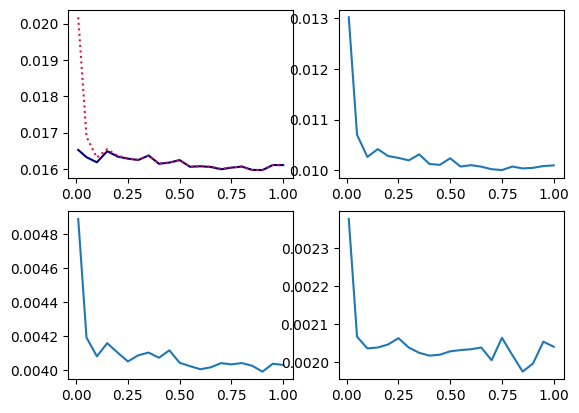

In [149]:
fig, ((axG, ax1), (ax2, ax3)) = plt.subplots(2, 2)
axG.plot(r_0s, [empirical_rhos[i][0] for i in range(len(r_0s))], color='navy')
axG.plot(r_0s, probs, color='crimson', ls=':')
ax1.plot(r_0s, [empirical_rhos[i][1] for i in range(len(r_0s))])
ax2.plot(r_0s, [empirical_rhos[i][2] for i in range(len(r_0s))])
ax3.plot(r_0s, [empirical_rhos[i][3] for i in range(len(r_0s))])
plt.show()

### TO DO Layer Overlap

As $\alpha \to \infty$, the assignment of affiliations is independent of space, and the density of layer $\ell$ tends to $\frac{1}{K^\ell}$. Independence of space implies indepence of affiliation choice across layers. Thus, the expected overlap in edges between two layers $\ell$ and $\ell'$ is $\frac{1}{K^\ell K^{\ell'}}$.

In [401]:
original_L = cfg.network.n_layers
original_K = cfg.network.n_affiliations
original_r_0 = cfg.connection.r_0
original_N = cfg.network.n_nodes

Ks = [random.randint(100,800),random.randint(100,800),random.randint(100,800)]

cfg.connection.r_0 = 100
cfg.network.n_layers = 3
cfg.network.n_affiliations = Ks
cfg.network.n_nodes = random.randint(1000,5000)

G, layers = gen(cfg, rng)

for l1, l2 in itertools.combinations(layers, 2):
    i = layers.index(l1)
    j = layers.index(l2)

    emp_prob = len(set(l1.edges).intersection(set(l2.edges))) / math.comb(cfg.network.n_nodes,2)
    est_prob = 1/(Ks[i]*Ks[j])
    print(f'The probability of an edge being in both layers {i+1} and {j+1} is {emp_prob:.6f} which is approximately {est_prob:.6f}, err={emp_prob/est_prob:.3f}.')


cfg.network.n_layers = original_L
cfg.network.n_affiliations = original_K
cfg.connection.r_0 = original_r_0
cfg.network.n_nodes = original_N

The probability of an edge being in both layers 1 and 2 is 0.000007 which is approximately 0.000007, err=0.916.
The probability of an edge being in both layers 1 and 3 is 0.000005 which is approximately 0.000005, err=1.039.
The probability of an edge being in both layers 2 and 3 is 0.000008 which is approximately 0.000007, err=1.175.


As $\alpha \to 0$ spatial dependence is high, and choice of affiliation is highly dependent across layers.

In [426]:
original_n_trials = cfg.analysis.mc.n_trials 
original_r_0 = cfg.connection.r_0

cfg.analysis.mc.n_trials = 100
cfg.connection.r_0 = 0.01

deltas = np.linspace(0,math.sqrt(2),51)[:-1]
p_deltas_100 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=100) for delta in deltas]
p_deltas_250 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=250) for delta in deltas]
p_deltas_500 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=500) for delta in deltas]

cfg.analysis.mc.n_trials = original_n_trials
cfg.connection.r_0 = original_r_0

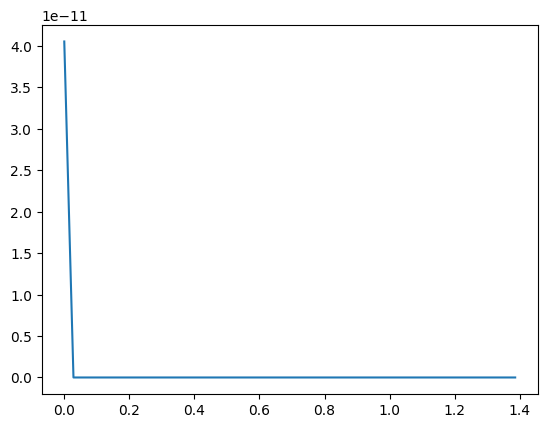

In [425]:
plt.plot(deltas, p_deltas_100)

Text(0, 0.5, 'Connection Probability')

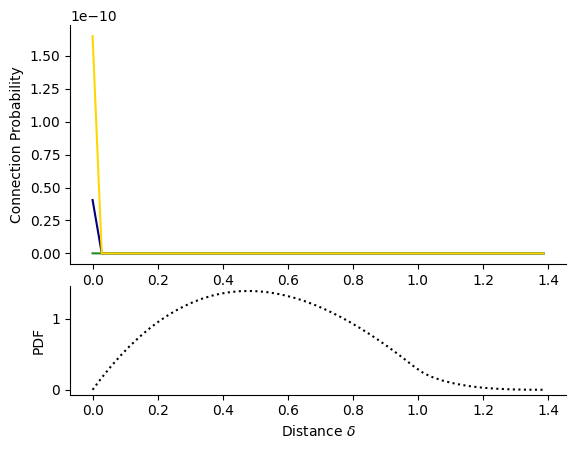

In [423]:
fig = plt.figure()
gs = plt.GridSpec(3, 1, figure=fig)
ax_pdeltas = fig.add_subplot(gs[:2,  0])
ax_sqprob = fig.add_subplot(gs[2, 0])

ax_pdeltas.plot(deltas, p_deltas_100, color='navy')
ax_pdeltas.plot(deltas, p_deltas_250, color='forestgreen')
ax_pdeltas.plot(deltas, p_deltas_500, color='gold')
ax_sqprob.plot(deltas, [sq_line_picking_prob(cfg, d) for d in deltas], ls=':', color='black')

ax_pdeltas.spines['top'].set_visible(False)
ax_pdeltas.spines['right'].set_visible(False)

ax_sqprob.spines['top'].set_visible(False)
ax_sqprob.spines['right'].set_visible(False)

ax_sqprob.set_ylabel("PDF")
ax_sqprob.set_xlabel("Distance $\\delta$")
ax_pdeltas.set_ylabel("Connection Probability")


8.198426621293237e-08


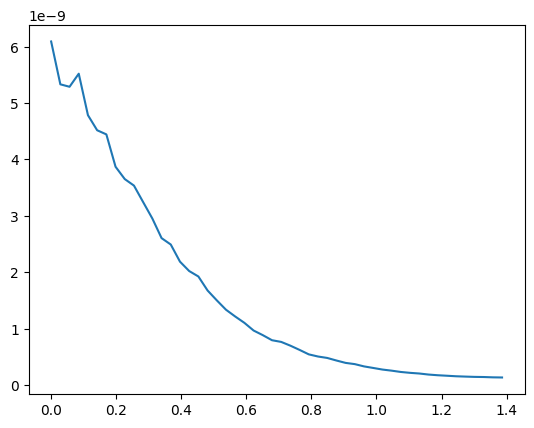

In [419]:
test = []
for i, delta in enumerate(deltas):
    test.append(p_deltas_100[i] * p_deltas_250[i])

plt.plot(deltas, test)
print(sum(test))

In [432]:
original_L = cfg.network.n_layers
original_K = cfg.network.n_affiliations
original_r_0 = cfg.connection.r_0
original_N = cfg.network.n_nodes

Ks = [100,250,500]

cfg.connection.r_0 = 0.01
cfg.network.n_layers = 3
cfg.network.n_affiliations = Ks
cfg.network.n_nodes = 1000

G, layers = gen(cfg, rng)

for l1, l2 in itertools.combinations(layers, 2):
    i = layers.index(l1)
    j = layers.index(l2)

    emp_prob = len(set(l1.edges).intersection(set(l2.edges))) / math.comb(cfg.network.n_nodes,2)
    est_prob = 1/(Ks[i]*Ks[j])
    print(f'The probability of an edge being in both layers {i+1} and {j+1} is {emp_prob:.6f} which is approximately {est_prob:.6f}, err={emp_prob/est_prob:.3f}.')


cfg.network.n_layers = original_L
cfg.network.n_affiliations = original_K
cfg.connection.r_0 = original_r_0
cfg.network.n_nodes = original_N

The probability of an edge being in both layers 1 and 2 is 0.002216 which is approximately 0.000040, err=55.405.
The probability of an edge being in both layers 1 and 3 is 0.001427 which is approximately 0.000020, err=71.371.
The probability of an edge being in both layers 2 and 3 is 0.000899 which is approximately 0.000008, err=112.362.


Text(0, 0.5, 'Connection Probability')

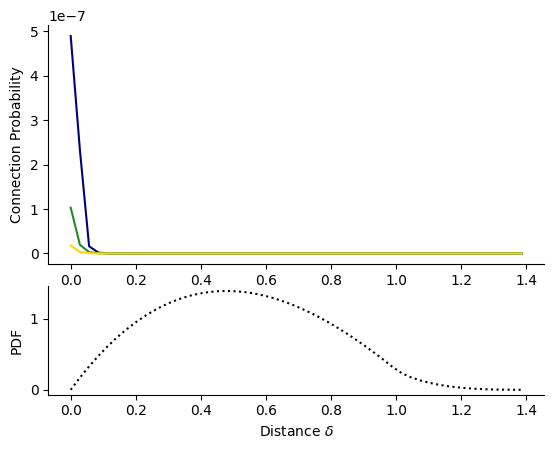

In [427]:
fig = plt.figure()
gs = plt.GridSpec(3, 1, figure=fig)
ax_pdeltas = fig.add_subplot(gs[:2,  0])
ax_sqprob = fig.add_subplot(gs[2, 0])

ax_pdeltas.plot(deltas, p_deltas_100, color='navy')
ax_pdeltas.plot(deltas, p_deltas_250, color='forestgreen')
ax_pdeltas.plot(deltas, p_deltas_500, color='gold')
ax_sqprob.plot(deltas, [sq_line_picking_prob(cfg, d) for d in deltas], ls=':', color='black')

ax_pdeltas.spines['top'].set_visible(False)
ax_pdeltas.spines['right'].set_visible(False)

ax_sqprob.spines['top'].set_visible(False)
ax_sqprob.spines['right'].set_visible(False)

ax_sqprob.set_ylabel("PDF")
ax_sqprob.set_xlabel("Distance $\\delta$")
ax_pdeltas.set_ylabel("Connection Probability")

In [430]:
total = 0 
for i, delta in enumerate(deltas):
    total += p_deltas_100[i] * p_deltas_250[i] * sq_line_picking_prob(cfg, delta)
total / len(deltas)

np.float64(1.5909853666705488e-17)

Workspace

In [23]:
def circle_union_area(delta, r):
    return r**2 * (2 * math.pi - 2 * math.acos(delta / (2*r)) + (delta / r) * math.sqrt(1 - (delta / (2*r))**2))

In [33]:
K = 100
delta = 0.1
print(K*circle_union_area(delta, 0.05))


1.5707963267948968


In [6]:
cfg

{'seed': 42,
 'n_runs': 10,
 'network': {'n_nodes': 1000,
  'n_layers': 5,
  'n_affiliations': [25, 50, 100, 200, 400],
  'layer_labels': ['l1', 'l2', 'l3', 'l4', 'l5']},
 'metric_space': {'square_side': 1,
  'distance': 'euclidean',
  'toroidal': False},
 'embedding': {'nodes': 'uniform', 'affiliations': 'uniform'},
 'connection': {'function': 'exponential_decay', 'alpha': 0.01},
 'visualization': {'plot_network': True,
  'plot_degree_distribution': True,
  'show': False},
 'analysis': {'omega_lookup_res': 101,
  'mc_n_trials': 100,
  'trapezoidal_res': 101},
 'output': {'plots': {'degree_dist': True,
   'degree_dist_layers': True,
   'embededness': True,
   'network_visualization': True,
   'save': True,
   'show': False}}}

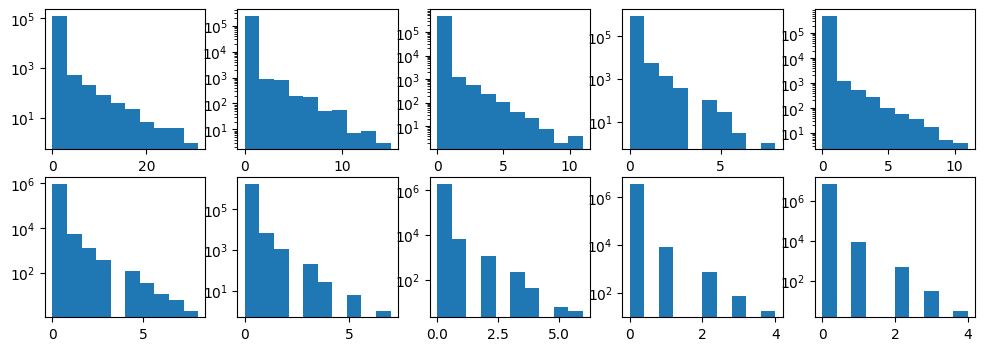

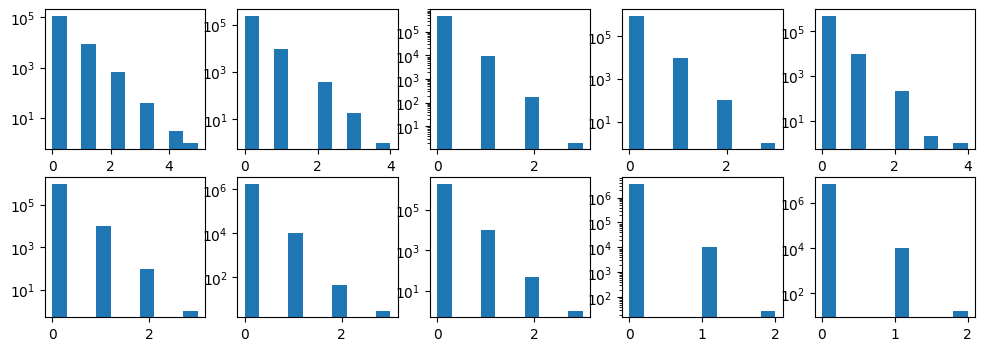

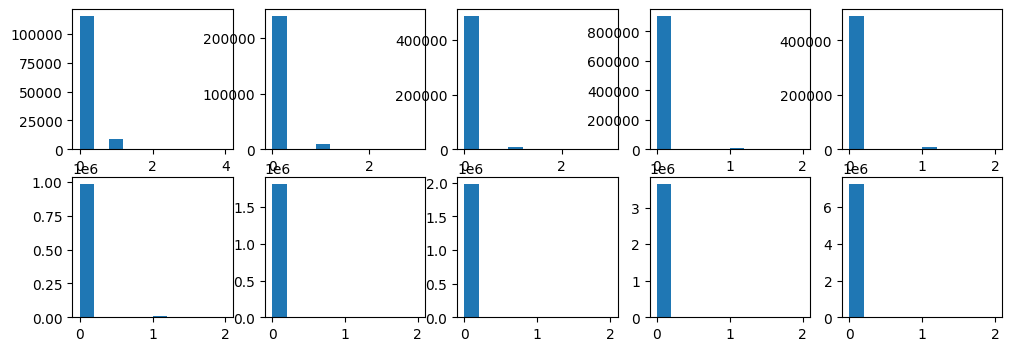

In [32]:
original_alpha = cfg.connection.alpha
original_N = cfg.network.n_nodes
original_Ks = cfg.network.n_affiliations

factor = 10
cfg.network.n_nodes = factor * original_N
cfg.network.n_affiliations = [factor*K for K in original_Ks]

cfg.connection.alpha = 0.01

fig, axs = plt.subplots(2, 5, figsize= (12,4))
axs = list(itertools.chain.from_iterable(axs))
ax_i = 0

G, layers = gen(cfg, rng)
layer_affiliations = []
for Gl in layers:
    affiliations = [clique for clique in nx.connected_components(Gl)]
    layer_affiliations.append(affiliations)
for i, j in itertools.combinations([i for i in range(cfg.network.n_layers)], 2):
    l1_affs = layer_affiliations[i]
    l2_affs = layer_affiliations[j]
    Os = []
    for l1_aff in l1_affs:
        for l2_aff in l2_affs:
            o = len(l1_aff.intersection(l2_aff))
            Os.append(o)
    axs[ax_i].hist(Os)
    axs[ax_i].set_yscale("log")
    ax_i += 1
plt.show()
            

cfg.connection.alpha = 0.1

fig, axs = plt.subplots(2, 5, figsize= (12,4))
axs = list(itertools.chain.from_iterable(axs))
ax_i = 0

G, layers = gen(cfg, rng)
layer_affiliations = []
for Gl in layers:
    affiliations = [clique for clique in nx.connected_components(Gl)]
    layer_affiliations.append(affiliations)
for i, j in itertools.combinations([i for i in range(cfg.network.n_layers)], 2):
    l1_affs = layer_affiliations[i]
    l2_affs = layer_affiliations[j]
    Os = []
    for l1_aff in l1_affs:
        for l2_aff in l2_affs:
            o = len(l1_aff.intersection(l2_aff))
            Os.append(o)
    axs[ax_i].hist(Os)
    axs[ax_i].set_yscale("log")
    ax_i += 1
plt.show()

cfg.connection.alpha = 1.0

fig, axs = plt.subplots(2, 5, figsize= (12,4))
axs = list(itertools.chain.from_iterable(axs))
ax_i = 0

G, layers = gen(cfg, rng)
layer_affiliations = []
for Gl in layers:
    affiliations = [clique for clique in nx.connected_components(Gl)]
    layer_affiliations.append(affiliations)
for i, j in itertools.combinations([i for i in range(cfg.network.n_layers)], 2):
    l1_affs = layer_affiliations[i]
    l2_affs = layer_affiliations[j]
    Os = []
    for l1_aff in l1_affs:
        for l2_aff in l2_affs:
            o = len(l1_aff.intersection(l2_aff))
            Os.append(o)
    axs[ax_i].hist(Os)
    #axs[ax_i].set_yscale("log")
    ax_i += 1
plt.show()

cfg.connection.alpha = original_alpha
cfg.network.n_nodes = original_N
cfg.network.n_affiliations = original_Ks

### TO DO Degree Distribution

Space-independent MSEAN graphs have binomially distributed affiliation sizes with probability $\frac 1 K$.
Voronoi MSEAN graphs have gamma distribution affiliation sizes.

Text(87, 0.72, 'Gamma')

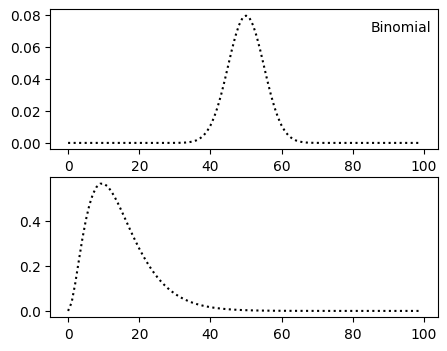

In [485]:
N = 100
K = 2
p = 1/K

alpha = 3
beta = 2.1

fig, axs = plt.subplots(2, 1, figsize=(5, 4))

xs = [i for i in range(N)]
y1s = [math.comb(N, k) * (p**k) * (1-p)**(N-k) for k in xs]
y2s = [beta**alpha / (math.gamma(alpha)) * (k/10)**(alpha - 1) * math.e**(-beta*(k/10)) for k in xs]
#y2s = [beta**alpha / (math.gamma(alpha)) * k**(alpha - 1) math.e**(-beta*k) for k in xs]

axs[0].plot(xs, y1s, ls=":", color='black')
axs[1].plot(xs, y2s, ls=":", color='black')

axs[0].annotate('Binomial', (85,0.07))
axs[1].annotate('Gamma', (87,0.72))

<h1> OLD

In [ ]:
plt.plot(np.linspace(0,1,51),[float(elem[0]) for elem in read_lookup_from_file("p_deltas_r025.csv")])
plt.xlabel('Distance $\\delta$')
plt.ylabel('$q_{\\delta}$')

In [340]:
deltas = np.linspace(0,1,51)
p_deltas = [float(elem[0]) for elem in read_lookup_from_file("p_deltas_r025.csv")]

OLD

In [191]:
G, layers = gen(cfg, rng)

In [192]:
edge_sets = [set(layer.edges) for layer in layers]

In [161]:
import itertools

In [218]:
ovs = [0,0,0]
n_trials = 100

for _ in range(n_trials):
    G, layers = gen(cfg, rng)
    for i, (l1, l2) in enumerate(itertools.combinations(range(cfg.network.n_layers), 2)):
        overlap = len(edge_sets[l1].intersection(edge_sets[l2]))
        ovs[i] += overlap / math.comb(cfg.network.n_nodes, 2)

ovs = [ov / n_trials for ov in ovs]

In [219]:
ovs

[3.8038038038038116e-05, 2.402402402402404e-05, 4.004004004003998e-06]

In [217]:
ovs

[3.803803803803804e-05, 2.4024024024024024e-05, 4.004004004004003e-06]

In [344]:
cfg.analysis.mc.n_trials = 1000

In [349]:
original_n_trials = cfg.analysis.mc.n_trials 
cfg.analysis.mc.n_trials = 20
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)
cfg.analysis.mc.n_trials = original_n_trials

In [356]:
weighting_lkup = read_lookup_from_file("weighting_lookup_r025.csv")
weighting_lkup = [[float(elem) for elem in row] for row in weighting_lkup]
weighting_coords = coord_vals = np.linspace(0, 1, cfg.analysis.mc.omega_lookup_res)

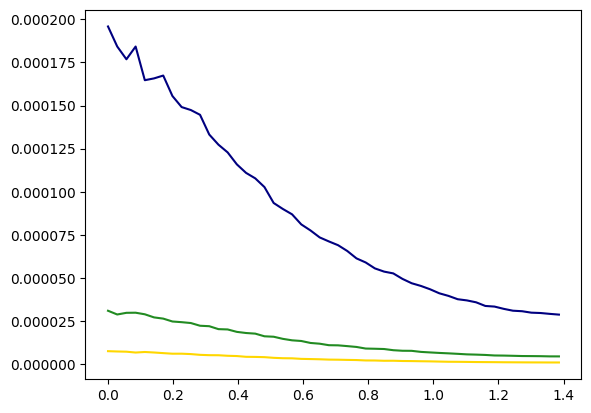

In [372]:
plt.plot(deltas, p_deltas_100, color='navy')
plt.plot(deltas, p_deltas_250, color='forestgreen')
plt.plot(deltas, p_deltas_500, color='gold')

In [373]:
original_L = cfg.network.n_layers
original_K = cfg.network.n_affiliations

cfg.network.n_layers = 3
cfg.network.n_affiliations = [100, 250, 500]
G, layers = gen(cfg, rng)

Overlap between layers with $K=100$ and $K=250$

In [375]:
total = 0
for i, delta in enumerate(deltas):
    total += p_deltas_100[i] * p_deltas_250[i] * sq_line_picking_prob(cfg, delta)
overlap = total / len(deltas)

In [376]:
overlap

np.float64(1.3355038818260768e-09)

In [380]:
len(set(layers[0].edges).intersection(set(layers[1].edges)))

26

In [381]:
E = len(layers[0].edges)
print(len(set(layers[0].edges).intersection(set(layers[1].edges))) / E)
print(overlap * E)

0.005095042132079169
6.81507630895847e-06


In [382]:
overlap / nx.density(layers[0])

np.float64(1.307239249406477e-07)

In [374]:
for l in layers:
    print(nx.density(l))

0.010216216216216217
0.004032032032032032
0.00207007007007007


OLD

In [211]:
deltas = np.linspace(0,math.sqrt(2),51)[:-1]
p_deltas_100 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=100) for delta in deltas]
p_deltas_250 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=250) for delta in deltas]
p_deltas_500 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=500) for delta in deltas]

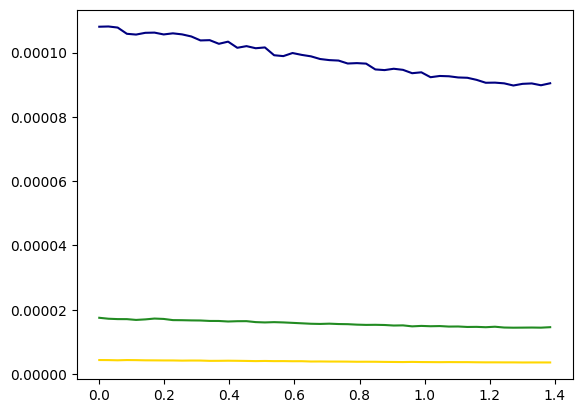

In [212]:
plt.plot(deltas, p_deltas_100, color='navy')
plt.plot(deltas, p_deltas_250, color='forestgreen')
plt.plot(deltas, p_deltas_500, color='gold')

In [213]:
total = 0
for i, delta in enumerate(deltas):
    total += p_deltas_100[i] * p_deltas_250[i] * sq_line_picking_prob(cfg, delta)
overlap = total / len(deltas)
print(overlap * math.comb(cfg.network.n_nodes, 2))

0.0005732372085783392


In [214]:
total = 0
for i, delta in enumerate(deltas):
    total += p_deltas_100[i] * p_deltas_500[i] * sq_line_picking_prob(cfg, delta)
overlap = total / len(deltas)
print(overlap * math.comb(cfg.network.n_nodes, 2))

0.00014354666567789593


In [215]:
total = 0
for i, delta in enumerate(deltas):
    total += p_deltas_250[i] * p_deltas_500[i] * sq_line_picking_prob(cfg, delta)
overlap = total / len(deltas)
print(overlap * math.comb(cfg.network.n_nodes, 2))

2.2968131675881097e-05


In [206]:
0.00002

2e-05

<h2> Density

original_n_trials = cfg.analysis.mc.n_trials 
original_r_0 = cfg.connection.r_0

cfg.analysis.mc.n_trials = 100
cfg.connection.r_0 = 0.01

deltas = np.linspace(0,math.sqrt(2),51)[:-1]
p_deltas_100 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=100) for delta in deltas]
p_deltas_250 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=250) for delta in deltas]
p_deltas_500 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=500) for delta in deltas]

cfg.analysis.mc.n_trials = original_n_trials
cfg.connection.r_0 = original_r_0

### TO DO Something else

In [33]:
G = gen(cfg, rng)

In [43]:
original_alpha = cfg.connection.alpha
alphas = [2**(-i/2) for i in range(1,21)]
meds = []
means = []

for alpha in alphas:
    cfg.connection.alpha = alpha
    G, _ = gen(cfg, rng)
    degs = [d for _, d in G.degree]
    meds.append(np.median(degs))
    means.append(np.mean(degs))


cfg.connection.alpha = alpha

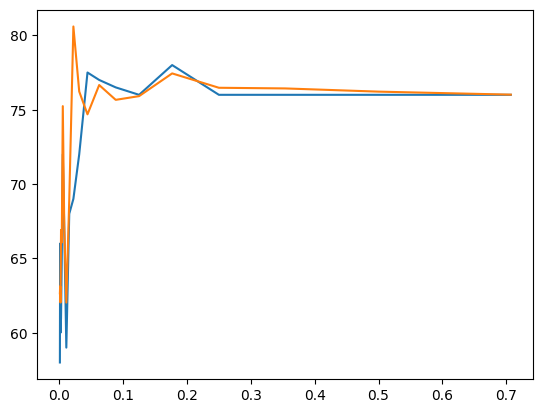

In [44]:
plt.plot(alphas, meds)
plt.plot(alphas, means)

### CURRENT TO DO Monoplex Density of Voronoi Case

The probability that two nodes $u$ and $v$ connect in the Voronoi scheme is the probability that there exists an affiliation $a^\ell_i$ which is closest to them both.
<br>
For a given affiliation position $\mathbf x_{a^\ell_i}$, the probability that it is closest to $\mathbf x_u$ and $\mathbf x_v$ is the void probability of the union of the circles centred at $\mathbf x_u$ and $\mathbf x_v$ with radii $d(\mathbf x_u, \mathbf x_{a^\ell_i})$ and $d(\mathbf x_v, \mathbf x_{a^\ell_i})$ respectively, in a Poisson Point Process with intensity $K^\ell$.

In [136]:
def trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K):
    """
    Trapezoidal approximation of the probability that two nodes at positions u_pos = (xᵤ, yᵤ) and v_pos = (xᵥ, yᵥ) connect in the Voronoi scheme.
    """
    total = 0 # Initialise total for numerical integration average.

    # Split sample space for affiliation positions into an n x n grid, where n = √cfg.analysis.mc_n_trials
    n = int(math.sqrt(cfg.analysis.mc_n_trials)) 
    for x_a in np.linspace(0, 1, n):
        for y_a in np.linspace(0, 1, n):
            a_pos = (x_a, y_a)

            # The probability that u chooses a is the void probability of the circle centred on u with radius d(u, a).
            area_u = math.pi * d(u_pos, a_pos, cfg)**2
            void_prob_u = math.e ** (-(K-1)*area_u)

            # The probability that v chooses a given that u chooses a is the void probability of the union of the circle centred on v with radius d(v, a) with the complement of the circle above centred on u.
            area_v = catchment_area(cfg, u_pos, v_pos, a_pos) - math.pi * d(u_pos, a_pos, cfg)**2
            void_prob_v = math.e ** (-(K-1)*area_v)

            # P(a(u) = a ∩ a(v) = a) = P(a(v) = a | a(u) = a)·P(a(u) = a)
            total += void_prob_u * void_prob_v
            
    return total / (n**2)

In [137]:
def mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K):
    """
    Monte-Carlo approximation of the probability that two nodes at positions u_pos = (xᵤ, yᵤ) and v_pos = (xᵥ, yᵥ) connect in the Voronoi scheme.
    """
    total = 0 # Initialise total for numerical integration average.

    # Take cfg.analysis.mc_n_trials samples of position for a
    for _ in range(cfg.analysis.mc_n_trials):
        a_pos = (random.uniform(0,1), random.uniform(0,1))

        # The probability that u chooses a is the void probability of the circle centred on u with radius d(u, a).
        area_u = math.pi * d(u_pos, a_pos, cfg)**2
        void_prob_u = math.e ** (-(K-1)*area_u)

        # The probability that v chooses a given that u chooses a is the void probability of the union of the circle centred on v with radius d(v, a) with the complement of the circle above centred on u.
        area_v = catchment_area(cfg, u_pos, v_pos, a_pos) - math.pi * d(u_pos, a_pos, cfg)**2
        void_prob_v = math.e ** (-(K-1)*area_v)

        # P(a(u) = a ∩ a(v) = a) = P(a(v) = a | a(u) = a)·P(a(u) = a)
        total += void_prob_u * void_prob_v
            
    return total / cfg.analysis.mc_n_trials

In [ ]:
def mc_voronoi_pairwise_delta_connection_prob(cfg, delta, K):
    """
    Monte-Carlo approximation of the probability that two nodes δ apart connect in the Voronoi scheme.
    """

    total = 0 # Initialise total for numerical integration average.

    # Take cfg.analysis.mc_n_trials samples of positions for u and 
    for _ in range(cfg.analysis.mc_n_trials):
        # Sample two uniform points inside the unit square a distance δ apart 
        v_pos = (-1, -1)
        while v_pos[0] < 0 or v_pos[0] > 1 or v_pos[1] < 0 or v_pos[1] > 1:
            u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
            theta = np.random.uniform(0, 2*math.pi)
            v_pos = (delta * math.cos(theta) + u_pos[0], delta * math.sin(theta) + u_pos[1])

        # Find P(u ~ v) by mc methods.
        total += K *mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K)

    return total / cfg.analysis.mc_n_trials

In [142]:
def trapezoidal_voronoi_pairwise_delta_connection_prob(cfg, delta, K):
    """
    Monte-Carlo approximation of the probability that two nodes δ apart connect in the Voronoi scheme, using a trapezoidal approximation for the connection probability. 
    """

    total = 0 # Initialise total for numerical integration average.

    # Take cfg.analysis.mc_n_trials samples of positions for u and 
    for _ in range(cfg.analysis.mc_n_trials):
        # Sample two uniform points inside the unit square a distance δ apart 
        v_pos = (-1, -1)
        while v_pos[0] < 0 or v_pos[0] > 1 or v_pos[1] < 0 or v_pos[1] > 1:
            u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
            theta = np.random.uniform(0, 2*math.pi)
            v_pos = (delta * math.cos(theta) + u_pos[0], delta * math.sin(theta) + u_pos[1])

        # Find P(u ~ v) by mc methods.
        total += K *trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, K)

    return total / cfg.analysis.mc_n_trials

<i> Do I need to make it toroidal?

In [182]:
cfg.analysis.mc_n_trials = 1000 # 1000

In [179]:
cfg.metric_space.toroidal = True

In [180]:
# Empirical tests

# Initialise values for δ and K.
deltas = np.linspace(0, 0.3, 51)
K = 100

# Initialise empty array for results
empirical_probs = [0 for _ in deltas]

# Iterate over all values of δ
for i, delta in enumerate(deltas):

    successes = 0 # Initialise to count successes

    for j in range(cfg.analysis.mc_n_trials):
        print(i, j)
        # Sample two uniform points a distance δ apart
        v_pos = (-1, -1)
        while v_pos[0] < 0 or v_pos[0] > 1 or v_pos[1] < 0 or v_pos[1] > 1:
            u_pos = (np.random.uniform(0,1), np.random.uniform(0,1))
            theta = np.random.uniform(0, 2*math.pi)
            v_pos = (delta * math.cos(theta) + u_pos[0], delta * math.sin(theta) + u_pos[1])

        # Generate K affiliation positions.
        aff_pos = {a : (np.random.uniform(0,1), np.random.uniform(0,1)) for a in range(K)}

        # Find the closest affiliation to u. 
        u_dist = {a: d(u_pos, aff_pos[a], cfg) for a in aff_pos}
        u_aff = min(u_dist, key=u_dist.get)

        # Find the closest affiliation to v. 
        v_dist = {a: d(v_pos, aff_pos[a], cfg) for a in aff_pos}
        v_aff = min(v_dist, key=v_dist.get)

        # u and v successfully connect if they choose the same affiliation. 
        successes += int(u_aff == v_aff)
        
    empirical_probs[i] = successes / cfg.analysis.mc_n_trials

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
0 30
0 31
0 32
0 33
0 34
0 35
0 36
0 37
0 38
0 39
0 40
0 41
0 42
0 43
0 44
0 45
0 46
0 47
0 48
0 49
0 50
0 51
0 52
0 53
0 54
0 55
0 56
0 57
0 58
0 59
0 60
0 61
0 62
0 63
0 64
0 65
0 66
0 67
0 68
0 69
0 70
0 71
0 72
0 73
0 74
0 75
0 76
0 77
0 78
0 79
0 80
0 81
0 82
0 83
0 84
0 85
0 86
0 87
0 88
0 89
0 90
0 91
0 92
0 93
0 94
0 95
0 96
0 97
0 98
0 99
0 100
0 101
0 102
0 103
0 104
0 105
0 106
0 107
0 108
0 109
0 110
0 111
0 112
0 113
0 114
0 115
0 116
0 117
0 118
0 119
0 120
0 121
0 122
0 123
0 124
0 125
0 126
0 127
0 128
0 129
0 130
0 131
0 132
0 133
0 134
0 135
0 136
0 137
0 138
0 139
0 140
0 141
0 142
0 143
0 144
0 145
0 146
0 147
0 148
0 149
0 150
0 151
0 152
0 153
0 154
0 155
0 156
0 157
0 158
0 159
0 160
0 161
0 162
0 163
0 164
0 165
0 166
0 167
0 168
0 169
0 170
0 171
0 172
0 173
0 174
0 175
0 176
0 177
0 178
0 179
0 180
0 181
0 182
0 183
0 184


In [183]:

# Calculate the analytical probability for all values of δ
analytical_mc_probs = [mc_voronoi_pairwise_delta_connection_prob(cfg, delta, K) for delta in deltas]

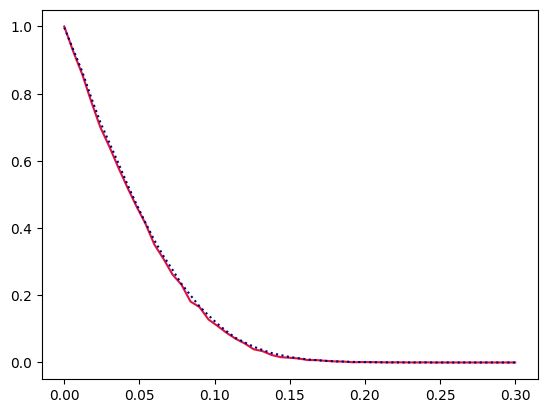

In [187]:
plt.plot(deltas, empirical_probs, c='crimson')
plt.plot(deltas, analytical_mc_probs, c='navy', ls=':')
plt.show()

In [184]:
sq_prob = [sq_line_picking_prob(cfg, delta) for delta in deltas]

In [185]:
prods = [sq_prob[i] * analytical_mc_probs[i] for i in range(len(deltas))]

In [186]:
sum(prods) / len(deltas)

np.float64(0.03918579363582909)

In [188]:
cfg.network.n_affiliations = [100]
cfg.network.n_layers = 1

In [193]:
G, _ = gen(cfg, rng)

In [ ]:
nx.density(G)

0.012362362362362362

: 

##### OLD NEEDS SORTING OUT

Delta Probs

In [4]:
def p_delta_voronoi(cfg, delta, K):
    """
    Monte-Carlo approximation of the probability of two nodes distance δ apart connecting.
    """
    total = 0
    for _ in range(cfg.analysis.mc_n_trials):
        # Sample uniformly from the set of points δ apart inside the unit square.
        x_v = -1
        y_v = -1 
        while not 0 <= x_v <= 1 or not 0 <= y_v <= 1:
            x_u, y_u = (random.uniform(0,1), random.uniform(0,1))
            theta = random.uniform(0,2 * math.pi) # Choose θ uniformly 
            x_v, y_v = (x_u + delta * math.cos(theta), y_u + delta * math.sin(theta)) # Find the point v which is δ away from u and 

        p = trapezoidal_voronoi_pairwise_connection_prob(cfg, (x_u, y_u), (x_v, y_v), K)
        total += p

    return total / cfg.analysis.mc_n_trials

In [5]:
def voronoi_density():
    total = 0
    deltas  = np.linspace(0, math.sqrt(2), 11)[:-1]
    for delta in deltas:
        prob_not_connected = 1
        for K in cfg.network.n_affiliations:
            p_delta = p_delta_voronoi(cfg, delta, K)
            prob_not_connected *= (1-p_delta)
        total += prob_not_connected * sq_line_picking_prob(cfg, delta)
    return total / len(deltas)

In [6]:
voronoi_density()

np.float64(0.6689924018666702)

In [12]:
deltas = np.linspace(0, math.sqrt(2), 101)[:-1]
probs  = [p_delta_voronoi(cfg, delta, 100) for delta in deltas]

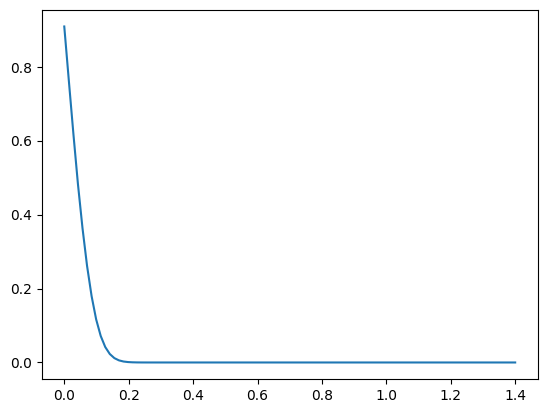

In [14]:
plt.plot(deltas, probs)

In [16]:
total = 0
for delta, prob in zip(deltas, probs):
    total += prob * sq_line_picking_prob(cfg, delta)
total /(len(deltas))

np.float64(0.007768390075611936)

In [31]:
trapezoidal_voronoi_pairwise_connection_prob(cfg, (x_u, y_u), (x_v, y_v), 1)

0.29433912597376927

In [37]:
K = 2

u_pos = (random.uniform(0,1), random.uniform(0,1))
v_pos = (random.uniform(0,1), random.uniform(0,1))
a_pos = (random.uniform(0,1), random.uniform(0,1))

print(u_pos, v_pos, a_pos)

area = catchment_area(cfg, u_pos, v_pos, a_pos)
void_prob = math.e ** (-(K-1)*area)
void_prob

(0.27986013154737455, 0.04677701027484138) (0.19429500486993412, 0.2664674916302716) (0.6631719493394471, 0.48770068010852585)


0.2932314329117709

Layer Overlap - Number of edges in both layers

In [ ]:
original_L = cfg.network.n_layers
original_Ks = cfg.network.n_affiliations
original_alpha = cfg.connection.alpha

cfg.network.n_layers = 2
cfg.network.n_affiliations = [100, 200]
cfg.connection.alpha = 0.001

n = 10000
total = 0
for _ in range(n):
    G, layers = gen(cfg, rng)
    l1_edges = set(layers[0].edges)
    l2_edges = set(layers[1].edges)

    total += len(l1_edges.intersection(l2_edges))
print(total / n)

cfg.network.n_layers = original_L
cfg.network.n_affiliations = original_Ks
cfg.connection.alpha = original_alpha

In [23]:
n = 100000

p = 0

for _ in range(n):
    u_pos = (random.uniform(0,1), random.uniform(0,1))
    v_pos = (random.uniform(0,1), random.uniform(0,1))

    p100 = trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 100)
    p200 = trapezoidal_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 200)
    p += p100 * p200

p /= n

p * math.comb(cfg.network.n_nodes, 2)

1285.6131743871324

In [24]:
n = 100000

p = 0

for _ in range(n):
    u_pos = (random.uniform(0,1), random.uniform(0,1))
    v_pos = (random.uniform(0,1), random.uniform(0,1))

    p100 = mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 100)
    p200 = mc_voronoi_pairwise_connection_prob(cfg, u_pos, v_pos, 200)
    p += p100 * p200

p /= n

p * math.comb(cfg.network.n_nodes, 2)

1391.7758122409375

In [1]:
gen

NameError: name 'gen' is not defined

To sort out

In [47]:
def p_delta_voronoi(cfg, delta, K):
    total = 0
    for _ in range(cfg.analysis.mc_n_trials):
        # Sample uniformly from the set of points δ apart inside the unit square.
        x_v = -1
        y_v = -1 
        while not 0 <= x_v <= 1 or not 0 <= y_v <= 1:
            x_u, y_u = (random.uniform(0,1), random.uniform(0,1))
            theta = random.uniform(0,2 * math.pi) # Choose θ uniformly 
            x_v, y_v = (x_u + delta * math.cos(theta), y_u + delta * math.sin(theta)) # Find the point v which is δ away from u and 

        total += prob_connecting((x_u, y_u), (x_v, y_v), K)

    return total / cfg.analysis.mc_n_trials

In [49]:
p_delta_voronoi(cfg, 0.1, 100)

0.0011416815742820712

In [48]:
p_delta_voronoi(cfg, 0.01, 100)

0.008182273144108498

In [50]:
p_delta_voronoi(cfg, 0.001, 100)

0.009218914434144914

In [58]:
def p_connect(cfg, K):
    total = 0
    for _ in range(10*cfg.analysis.mc_n_trials):
        # Sample uniformly from the set of points inside the unit square.
        x_u, y_u = (random.uniform(0,1), random.uniform(0,1))
        x_v, y_v = (random.uniform(0,1), random.uniform(0,1))

        total += prob_connecting((x_u, y_u), (x_v, y_v), K)

    return total / (10*cfg.analysis.mc_n_trials)

In [59]:
p_connect(cfg, 100)

9.783866059048514e-05

In [ ]:
x_u = 0.5
y_u = 0.5
x_v = 0.46
y_v = 0.4

K = 100

print(trapezoidal_pairwise_connection_prob)
print(K*prob_connecting((x_u, y_u), (x_v, y_v), K))


0.09068046142049191
